In [102]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

from google.colab import files
uploaded=files.upload()

Saving covid_19_clean_complete.csv to covid_19_clean_complete.csv


In [103]:
df_covid19=pd.read_csv("covid_19_clean_complete.csv")
df_covid19.head()


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [104]:
df_covid19.drop(columns=["Province/State"], inplace=True)   ## Blank Column removal

In [105]:
df_covid19.head()

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [106]:
df_covid19.info()
df_covid19.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country/Region  49068 non-null  object 
 1   Lat             49068 non-null  float64
 2   Long            49068 non-null  float64
 3   Date            49068 non-null  object 
 4   Confirmed       49068 non-null  int64  
 5   Deaths          49068 non-null  int64  
 6   Recovered       49068 non-null  int64  
 7   Active          49068 non-null  int64  
 8   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(3)
memory usage: 3.4+ MB


,0
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [107]:
df_covid19["Country/Region"].nunique()  ### 187 unique countries are here in this dataset

187

In [108]:
df_covid19["WHO Region"].nunique() ## 6 WHO Region

6

In [109]:
connect=sqlite3.connect("COVID19.db")
df_covid19.to_sql("covid19", connect, if_exists="replace", index=False)

pd.read_sql_query("""select * from covid19 limit 3;""", connect)

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa


## Region ranks based on their counts

In [110]:
pd.read_sql_query("""select "WHO Region",  dense_rank() over (order by counts desc) as region_rank from
(select "WHO Region", count("WHO Region") as counts  from covid19 group by "WHO Region") as t;""", connect)

,WHO Region,region_rank
0,Europe,1
1,Western Pacific,2
2,Africa,3
3,Americas,4
4,Eastern Mediterranean,5
5,South-East Asia,6


## Country ranks based on their counts

In [111]:
pd.read_sql_query("""select "Country/Region",  dense_rank() over (order by country_counts desc) as region_rank from
(select "Country/Region", count("Country/Region") as country_counts  from covid19 group by "Country/Region") as t;""", connect)

,Country/Region,region_rank
0,China,1
1,Canada,2
2,France,3
3,United Kingdom,3
4,Australia,4
...,...,...
182,West Bank and Gaza,7
183,Western Sahara,7
184,Yemen,7
185,Zambia,7


## Country ranks based on total_deaths

In [112]:
pd.read_sql_query("""select "Country/Region", total_deaths, dense_rank() over (order by total_deaths desc) as country_rank
from (select "Country/Region", max(Deaths) AS total_deaths from covid19 group by "Country/Region") as t;""", connect)


,Country/Region,total_deaths,country_rank
0,US,148011,1
1,Brazil,87618,2
2,United Kingdom,45759,3
3,Mexico,44022,4
4,Italy,35112,5
...,...,...,...
182,Saint Lucia,0,150
183,Saint Vincent and the Grenadines,0,150
184,Seychelles,0,150
185,Timor-Leste,0,150


## Top 10 Country with highest deaths  

In [113]:


pd.read_sql_query("""select"Country/Region", max(deaths) as total_deaths, max("recovered") as total_recoverd,
                      max(active) as total_active from covid19
                      group by "Country/Region" order by max(deaths) desc limit 10;""", connect)
## US faced highest deaths 	11011411

,Country/Region,total_deaths,total_recoverd,total_active
0,US,148011,1325804,2816444
1,Brazil,87618,1846641,583080
2,United Kingdom,45759,533,254352
3,Mexico,44022,303810,53572
4,Italy,35112,198593,108257
5,India,33408,951166,495499
6,France,30096,72408,107072
7,Spain,28752,150376,101617
8,Peru,18418,272547,108616
9,Iran,15912,255144,34887


/tmp/ipython-input-1766642405.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10["Country/Region"], y=top_10["Deaths"], palette="magma")


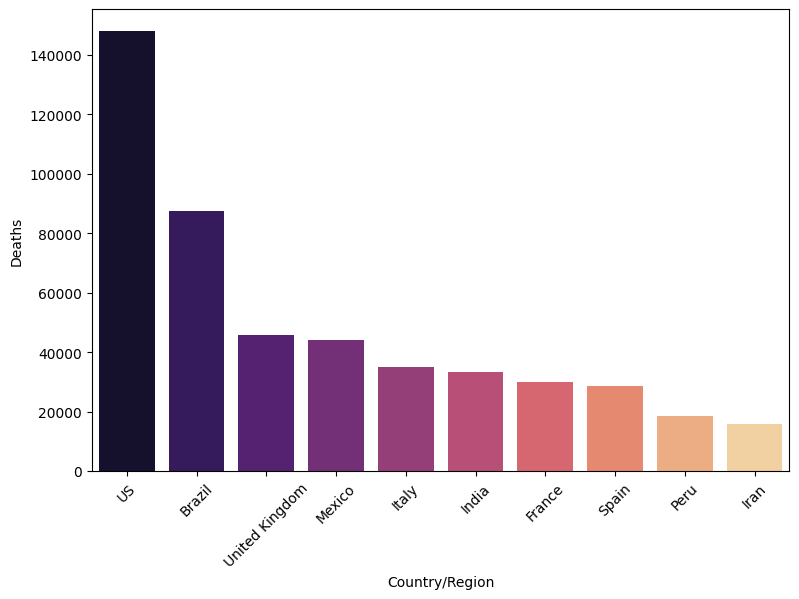

In [114]:
### Top 10 Country with highest deaths

top_10= df_covid19.groupby("Country/Region")[["Confirmed", "Deaths", "Recovered", "Active"]].max().sort_values(by="Deaths", ascending=False).reset_index().head(10)
top_10
plt.figure(figsize=(9,6))
sns.barplot(x=top_10["Country/Region"], y=top_10["Deaths"], palette="magma")
plt.xticks(rotation=45)
plt.show()

## Highest number of new cases update over time

In [115]:


pd.read_sql_query("""
select "Country/Region" AS country,
    Date,
    Confirmed - coalesce(LAG(Confirmed) OVER (PARTITION BY [Country/Region] ORDER BY Date), 0) AS new_cases
FROM covid19 order by new_cases desc limit 1;
""", connect)

### United Kingdom has higest number of new cases.


,country,Date,new_cases
0,United Kingdom,2020-07-27,300099


## Top 10 countries with highest number of daily new cases

In [116]:
pd.read_sql_query("""
WITH daily_cases AS (
    SELECT
        "Country/Region" AS country,
        Date,
        Confirmed - COALESCE(LAG(Confirmed) OVER (PARTITION BY "Country/Region" ORDER BY Date), 0) AS new_cases FROM covid19 )
SELECT
    country,
    MAX(new_cases) AS max_daily_new_cases
FROM daily_cases
GROUP BY country
ORDER BY max_daily_new_cases DESC
LIMIT 10;
""", connect)


,country,max_daily_new_cases
0,United Kingdom,300099
1,France,208396
2,US,77255
3,Brazil,67860
4,China,67652
5,Canada,58692
6,Netherlands,53037
7,India,49981
8,Kazakhstan,18757
9,Colombia,16306


## Daily New COVID-19 Cases in all the  Countries

In [117]:

## Daily New COVID-19 Cases in all Countries

df_all_peak_Countries = pd.read_sql_query("""
Select * from (select "Country/Region" as country, Date, Confirmed - coalesce(lag (Confirmed) OVER
          (partition by "Country/Region" order by Date), 0) AS new_cases FROM covid19) as t where new_cases >= 0;""", connect)

df_all_peak_Countries



,country,Date,new_cases
0,Afghanistan,2020-01-22,0
1,Afghanistan,2020-01-23,0
2,Afghanistan,2020-01-24,0
3,Afghanistan,2020-01-25,0
4,Afghanistan,2020-01-26,0
...,...,...,...
42419,Zimbabwe,2020-07-23,90
42420,Zimbabwe,2020-07-24,172
42421,Zimbabwe,2020-07-25,138
42422,Zimbabwe,2020-07-26,78


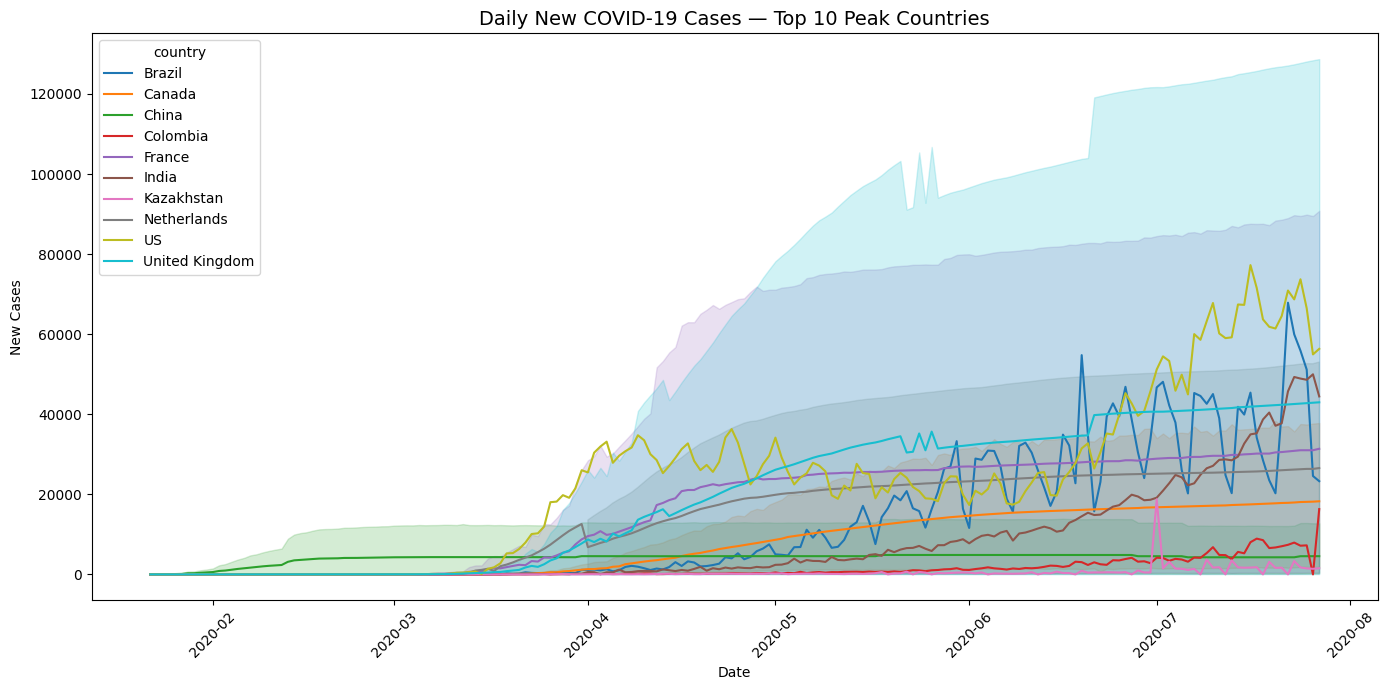

In [118]:

df_all_peak_Countries["Date"] = pd.to_datetime(df_all_peak_Countries["Date"])


top10 = (
    df_all_peak_Countries.groupby("country")["new_cases"].max().sort_values(ascending=False).head(10).index
    .tolist()
)


# Filter dataset for only those 10 countries
df_top10 = df_all_peak_Countries[df_all_peak_Countries["country"].isin(top10)]

plt.figure(figsize=(14,7))
sns.lineplot(data=df_top10, x="Date", y="new_cases", hue="country")

plt.title("Daily New COVID-19 Cases — Top 10 Peak Countries", fontsize=14)
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## COVID 19 deaths over time in United Kingdom  

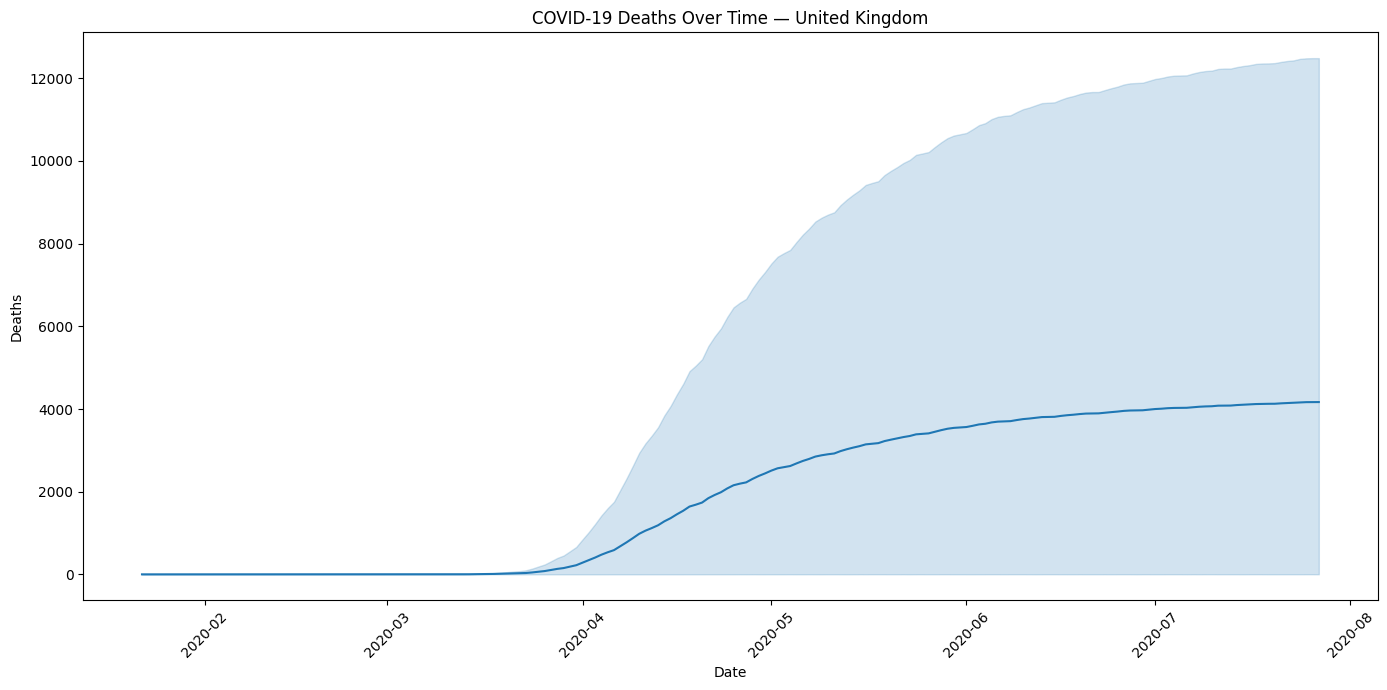

In [119]:
df = pd.read_sql_query("""
SELECT
    "Country/Region" AS country,
    Date,
    Deaths
FROM covid19
WHERE "Country/Region" = 'United Kingdom'
ORDER BY Date;
""", connect)

df["Date"] = pd.to_datetime(df["Date"])

plt.figure(figsize=(14,7))
sns.lineplot(data=df, x="Date", y="Deaths")

plt.title("COVID-19 Deaths Over Time — United Kingdom")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## COVID 19 deaths trend in WHO regions

In [120]:
pd.read_sql_query("select * from covid19", connect)

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...
49063,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


## Daily cases and deaths in WHO regions

In [121]:
df_who_trend = pd.read_sql_query("""select "WHO Region" , Date,
    sum(Confirmed) as daily_cases,
    sum(Deaths) as daily_deaths
from covid19
group by "WHO Region", Date
order by "WHO Region", Date;
""", connect)
df_who_trend

 ### Used SUM() for regional daily totals because a region contains multiple countries;
 ### MAX() would only give the largest country’s value.

,WHO Region,Date,daily_cases,daily_deaths
0,Africa,2020-01-22,0,0
1,Africa,2020-01-23,0,0
2,Africa,2020-01-24,0,0
3,Africa,2020-01-25,0,0
4,Africa,2020-01-26,0,0
...,...,...,...,...
1123,Western Pacific,2020-07-23,277192,8131
1124,Western Pacific,2020-07-24,280946,8148
1125,Western Pacific,2020-07-25,284973,8180
1126,Western Pacific,2020-07-26,289139,8225


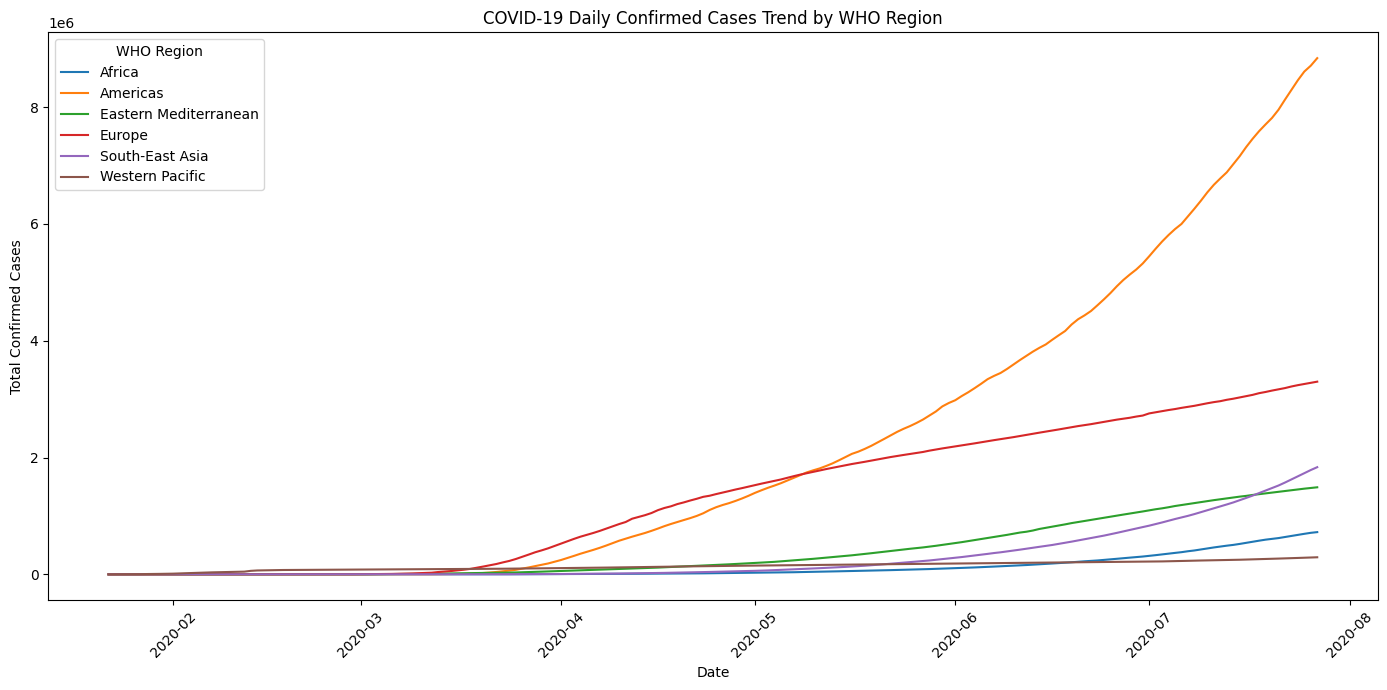

In [122]:
df_who_trend["Date"] = pd.to_datetime(df_who_trend["Date"])

plt.figure(figsize=(14,7))
sns.lineplot(data=df_who_trend, x="Date", y="daily_cases", hue="WHO Region")
plt.title("COVID-19 Daily Confirmed Cases Trend by WHO Region")
plt.xlabel("Date")
plt.ylabel("Total Confirmed Cases")
plt.xticks(rotation=45)
plt.tight_layout()                             ### America faced highest daily confirmed cases.
plt.show()

## Country wise case fatality and case recovery rates

In [123]:
df_country_rates = pd.read_sql_query("""
select
    "Country/Region" as country,
    max(Confirmed) as total_confirmed,
    max(Deaths) as total_deaths,
    max(Recovered) as total_recovered,
    round(MAX(Deaths)*100.0 / max(Confirmed), 4) as case_fatality_rate,
    round(MAX(Recovered)*100.0 / max(Confirmed), 4) as case_recovery_rate
from covid19
group by "Country/Region"
having max(Confirmed) > 0
order by case_fatality_rate DESC limit 10;
""", connect)
df_country_rates   ### Yemen had highest case fatality rate and recovery rate dure is low population of confirmed cases (1691).

## The COVID-19 dataset contains cumulative daily totals,
## so using  SUM() would incorrectly inflate values by adding each day’s cumulative count.
## To obtain accurate final totals, MAX() is the correct choice because it represents the latest cumulative value for each country or region.

,country,total_confirmed,total_deaths,total_recovered,case_fatality_rate,case_recovery_rate
0,Yemen,1691,483,833,28.5630,49.2608
1,United Kingdom,300111,45759,533,15.2474,0.1776
2,Belgium,66428,9822,17452,14.7859,26.2721
3,France,208665,30096,72408,14.4231,34.7006
4,Italy,246286,35112,198593,14.2566,80.6351
5,Hungary,4448,596,3329,13.3993,74.8426
6,Netherlands,53151,6141,102,11.5539,0.1919
7,Mexico,395489,44022,303810,11.1310,76.8188
8,Spain,272421,28752,150376,10.5543,55.1999
9,Western Sahara,10,1,8,10.0000,80.0000


/tmp/ipython-input-494476636.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_country_rates, x="country", y="case_fatality_rate", palette="magma")


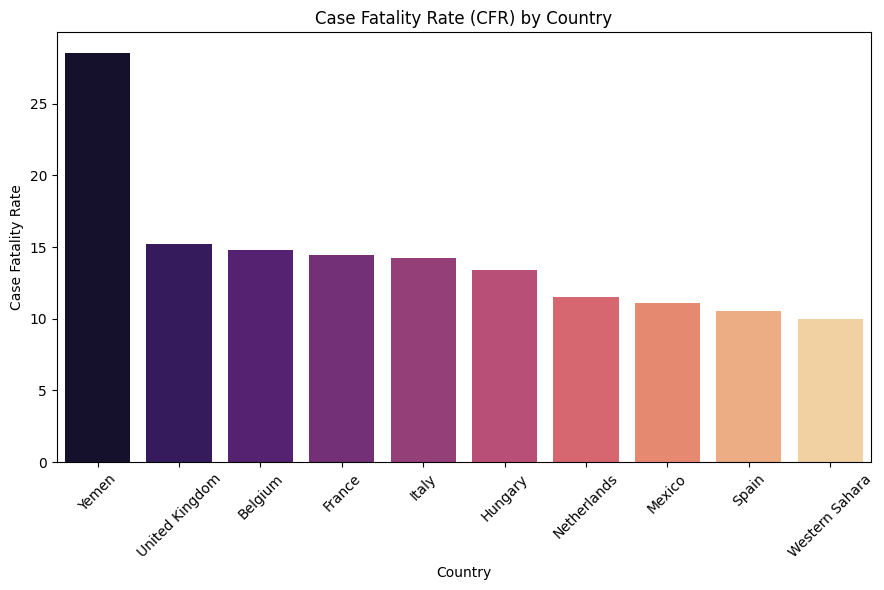

In [124]:
plt.figure(figsize=(9,6))
sns.barplot(data=df_country_rates, x="country", y="case_fatality_rate", palette="magma")
plt.title("Case Fatality Rate (CFR) by Country")
plt.xlabel("Country")
plt.ylabel("Case Fatality Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## WHO region wise case fatality rate and case recovery rate  

In [125]:

df_region_rates = pd.read_sql_query("""
select
    "WHO Region" as region,
    max(Confirmed) as total_confirmed,
    max(Deaths) as total_deaths,
    max(Recovered) as total_recovered,
    round(MAX(Deaths)*100.0 / max(Confirmed), 2) as case_fatality_rate,
    round(MAX(Recovered)*100.0 / max(Confirmed), 2) as case_recovery_rate
from covid19
group by "WHO Region"
having max(Confirmed) > 0
order by case_fatality_rate DESC;
""", connect)
df_region_rates
                             ### Europe has the highest case fatality rate.

,region,total_confirmed,total_deaths,total_recovered,case_fatality_rate,case_recovery_rate
0,Europe,816680,45759,602249,5.60,73.74
1,Western Pacific,82040,4512,64435,5.50,78.54
2,Eastern Mediterranean,293606,15912,255144,5.42,86.90
3,Americas,4290259,148011,1846641,3.45,43.04
4,South-East Asia,1480073,33408,951166,2.26,64.26
5,Africa,452529,7067,274925,1.56,60.75


## WHO region wise case fatality and recovery rates

In [126]:
df_who_region=pd.read_sql_query("""
Select "WHO Region",
       max(Confirmed) AS total_confirmed_cases,
       max(Deaths) AS total_deaths,
        ROUND(MAX(Deaths) * 100.0 / MAX(Confirmed), 2) AS case_fatality_rate,
         ROUND(MAX(Recovered) * 100.0 / MAX(Confirmed), 2) AS case_recovery_rate
FROM covid19
GROUP BY "WHO Region"
ORDER BY total_deaths DESC;
""", connect)
df_who_region                    ### Europe has highest case fatality rate amoung all the WHO regions

,WHO Region,total_confirmed_cases,total_deaths,case_fatality_rate,case_recovery_rate
0,Americas,4290259,148011,3.45,43.04
1,Europe,816680,45759,5.60,73.74
2,South-East Asia,1480073,33408,2.26,64.26
3,Eastern Mediterranean,293606,15912,5.42,86.90
4,Africa,452529,7067,1.56,60.75
5,Western Pacific,82040,4512,5.50,78.54


/tmp/ipython-input-1554659825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_region_rates, x="region", y="case_fatality_rate", palette="viridis")


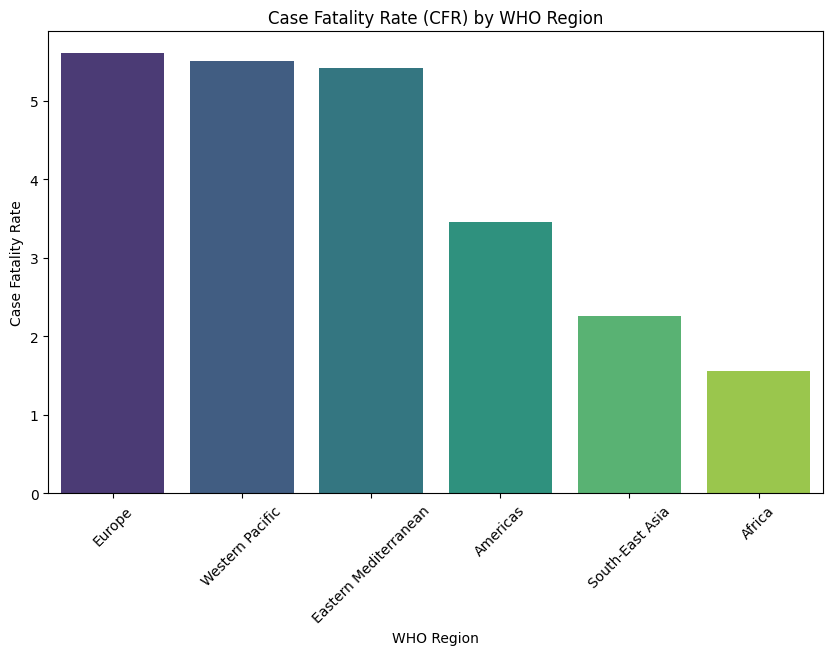

In [127]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_region_rates, x="region", y="case_fatality_rate", palette="viridis")
plt.title("Case Fatality Rate (CFR) by WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Case Fatality Rate")
plt.xticks(rotation=45)
plt.show()


## Correlation analysis of Confirmed and Deaths

In [128]:
# Load final-country totals (since Confirmed/Deaths are cumulative daily values)
df_correlation = pd.read_sql_query("""
select
    "Country/Region" AS country,
    max(Confirmed) AS confirmed,
    max(Deaths) AS deaths,
    max(Recovered) AS recovered
from covid19
group by  "Country/Region"
having confirmed > 0;
""", connect)


In [129]:
corr_confirmed_deaths = df_correlation['confirmed'].corr(df_correlation['deaths'])

corr_confirmed_deaths               ### strong correlation between confirmed cases and deaths (0.934)

np.float64(0.9346208909224282)

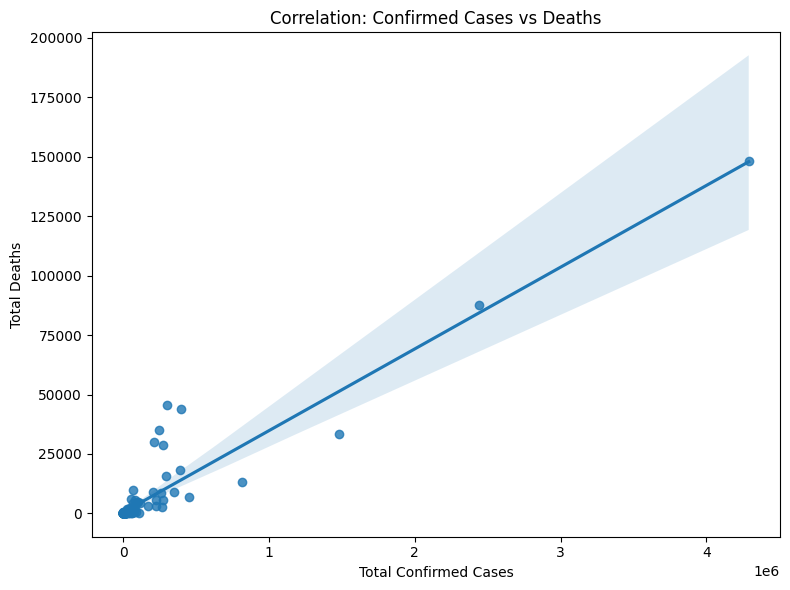

In [130]:
plt.figure(figsize=(8,6))
sns.regplot (x=df_correlation["confirmed"], y=df_correlation["deaths"])

plt.title("Correlation: Confirmed Cases vs Deaths")
plt.xlabel("Total Confirmed Cases")
plt.ylabel("Total Deaths")
plt.tight_layout()
plt.show()


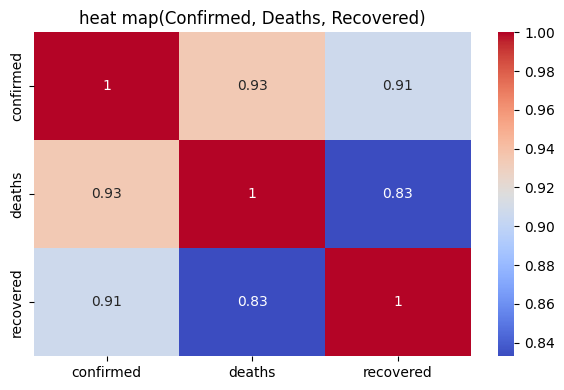

In [131]:
plt.figure(figsize=(6,4))
sns.heatmap(df_correlation[['confirmed', 'deaths', 'recovered']].corr(),
            annot=True, cmap="coolwarm")

plt.title("heat map(Confirmed, Deaths, Recovered)")
plt.tight_layout()
plt.show()


## Statistical analysis of CFR over regions

---



In [132]:
df_cfr = pd.read_sql_query("""
SELECT
    "Country/Region" AS country,
    "WHO Region" AS region,
    MAX(Deaths) * 100.0 /MAX(Confirmed) AS CFR
FROM covid19
GROUP BY "Country/Region"

""", connect)


In [133]:
df_cfr.groupby("region")["CFR"].count()


,CFR
region,
Africa,48
Americas,35
Eastern Mediterranean,22
Europe,56
South-East Asia,10
Western Pacific,16


In [134]:
import scipy.stats as stats

from scipy.stats import f_oneway

# Unique WHO regions
regions = df_cfr['region'].unique()

# Prepare groups for ANOVA (CFR values per region)
groups = [df_cfr[df_cfr['region'] == r]['CFR'] for r in regions]

# Run ANOVA
anova_result = f_oneway(*groups)

anova_result




F_onewayResult(statistic=np.float64(3.184105316776193), pvalue=np.float64(0.008841451620933569))

When including all countries, ANOVA detects significant differences in CFR across WHO regions (p = 0.0088).
However, when filtering out countries with fewer than 1000 confirmed cases, the difference is no longer statistically significant (p = 0.0539).
This indicates that extreme CFR values in small-population countries heavily influence the results, and regional differences are less pronounced among larger nations with more stable reporting.